# TS5
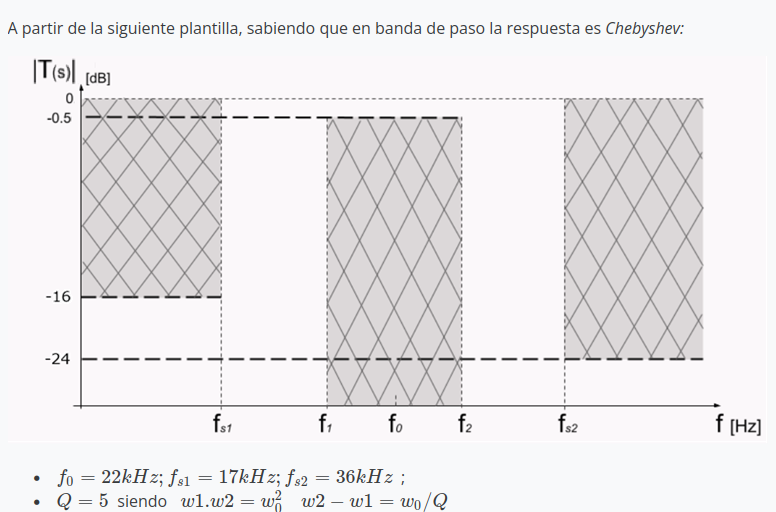

### Obtener la plantilla de atenuación normalizada en frecuencia.  Indicar los valores de αmax y de αmin

![TS5_1](images/TS5_1.png)

### Obtener la función transferencia normalizada del prototipo pasa bajo que satisfaga el requerimiento del filtro pasa banda.

![TS5_1](images/TS5_2.png)
![TS5_1](images/TS5_3.png)
![TS5_1](images/TS5_4.png)


La **transferencia normalizada** del prototipo pasa-bajos que satisface las condiciones especificadas es de **orden tres**.

Su función de transferencia normalizada queda descripta entonces por:

$$
T_{LPF}(s) = \frac{1}{s + 1} \cdot \frac{1}{s^2 + \frac{s}{Q} + 1}
$$

Donde el primer término representa el filtro **pasa-bajos** de primer orden  
y el segundo término representa un filtro **pasa-bajos** de segundo orden con factor de calidad \( **Q=5** \).

### Aplicar el núcleo de transformación pasa banda y obtener la transferencia. Factorizar convenientemente para expresar en SOS.

![TS5_1](images/TS5_5.png)
![TS5_1](images/TS5_6.png)
![TS5_1](images/TS5_7.png)
![TS5_1](images/TS5_8.png)

### Realizar la simulación numérica en python. Graficar la respuesta en frecuencia del filtro pasa banda total, y las de las SOS. 

### Filtro pasa Bajos de orden 3

<IPython.core.display.Math object>

### Filtro pasa banda de orden 6 SOS(ignorar el S al cuadrado)

<IPython.core.display.Math object>

### Filtro pasa banda de orden 6 no SOS(ignorar el S al cuadrado)

<IPython.core.display.Math object>

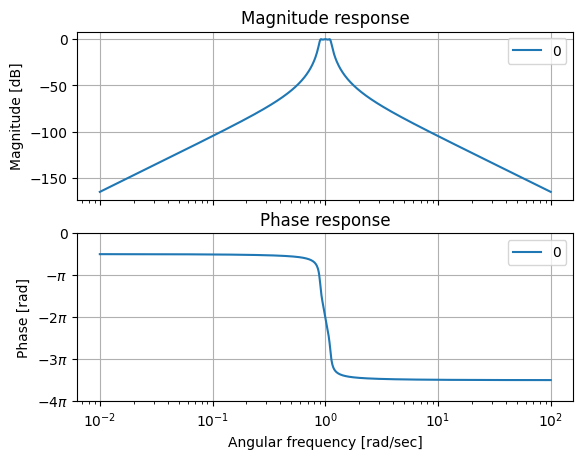

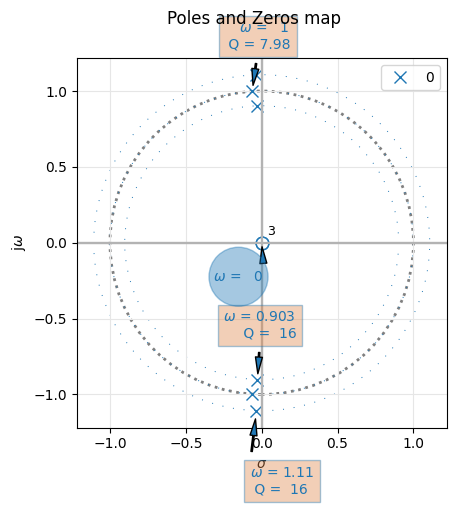

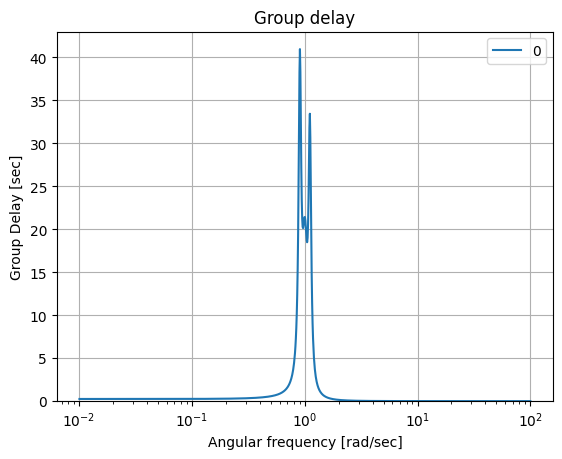

In [11]:
from scipy.signal import TransferFunction
from pytc2.sistemas_lineales import analyze_sys, pretty_print_bicuad_omegayq, tf2sos_analog, pretty_print_SOS, pretty_print_lti
import numpy as np
import sympy as sp
from scipy import signal as sig
import matplotlib.pyplot as plt
from IPython.display import display, Markdown


ripple = 0.5
n = 3
Q=5
e = np.sqrt( 10**(ripple/10) - 1 )

z,p,k = sig.cheb1ap(n, 0.5)

display(Markdown("### Filtro pasa Bajos de orden 3"))
num, den = sig.zpk2tf(z,p,k) # pasa a transfer function 
sos = tf2sos_analog(num, den)

pretty_print_SOS(sos, mode='omegayq')

display(Markdown("### Filtro pasa banda de orden 6 SOS(ignorar el S al cuadrado)"))
num, den = sig.lp2bp(num, den,bw=(1/Q)) # de pasa bajos a pasa banda 
sos = tf2sos_analog(num, den)
pretty_print_SOS(sos, mode='omegayq')
display(Markdown("### Filtro pasa banda de orden 6 no SOS(ignorar el S al cuadrado)"))

pretty_print_lti(num,den)
analyze_sys( sig.TransferFunction(num,den), same_figs=False )